# **1. DATA LOADING**

In [ ]:
import pandas as pd
import os

# List of files provided in the kernel
files = [
    'olist_customers_dataset.csv',
    'olist_geolocation_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_order_reviews_dataset.csv',
    'olist_orders_dataset.csv',
    'olist_products_dataset.csv',
    'olist_sellers_dataset.csv',
    'product_category_name_translation.csv'
]

data = {}
for file in files:
    df = pd.read_csv(f'/content/{file}')
    table_name = file.replace('.csv', '')
    data[table_name] = df

for table, df_obj in data.items():
    print(f"- Table {table}:")
    for col in df_obj.columns:
        print(f"  + {col}: ")

- Table olist_customers_dataset:
  + customer_id: 
  + customer_unique_id: 
  + customer_zip_code_prefix: 
  + customer_city: 
  + customer_state: 
- Table olist_geolocation_dataset:
  + geolocation_zip_code_prefix: 
  + geolocation_lat: 
  + geolocation_lng: 
  + geolocation_city: 
  + geolocation_state: 
- Table olist_order_items_dataset:
  + order_id: 
  + order_item_id: 
  + product_id: 
  + seller_id: 
  + shipping_limit_date: 
  + price: 
  + freight_value: 
- Table olist_order_payments_dataset:
  + order_id: 
  + payment_sequential: 
  + payment_type: 
  + payment_installments: 
  + payment_value: 
- Table olist_order_reviews_dataset:
  + review_id: 
  + order_id: 
  + review_score: 
  + review_comment_title: 
  + review_comment_message: 
  + review_creation_date: 
  + review_answer_timestamp: 
- Table olist_orders_dataset:
  + order_id: 
  + customer_id: 
  + order_status: 
  + order_purchase_timestamp: 
  + order_approved_at: 
  + order_delivered_carrier_date: 
  + order_deliv

# **2. DATA DICTIONARY**

Based on the inspection, here is the clear description of the tables and their columns:

### **1. Table: olist_customers_dataset**
* **customer_id:** Key to the orders dataset. Each order has a unique customer_id.
* **customer_unique_id:** Unique identifier of a customer.
* **customer_zip_code_prefix:** First five digits of customer zip code.
* **customer_city:** Customer city name.
* **customer_state:** Customer state.

### **2. Table: olist_geolocation_dataset**
* **geolocation_zip_code_prefix:** First five digits of zip code.
* **geolocation_lat:** Latitude.
* **geolocation_lng:** Longitude.
* **geolocation_city:** City name.
* **geolocation_state:** State.

### **3. Table: olist_order_items_dataset**
* **order_id:** Order unique identifier.
* **order_item_id:** Sequential number identifying number of items included in the same order.
* **product_id:** Product unique identifier.
* **seller_id:** Seller unique identifier.
* **shipping_limit_date:** Seller shipping limit date for handling the order.
* **price:** Item price.
* **freight_value:** Item freight value item (if an order has more than one item the freight value is split between items).

### **4. Table: olist_order_payments_dataset**
* **order_id:** Order unique identifier.
* **payment_sequential:** A customer may pay an order with more than one payment method.
* **payment_type:** Method of payment chosen by the customer.
* **payment_installments:** Number of installments chosen by the customer.
* **payment_value:** Transaction value.

### **5. Table: olist_order_reviews_dataset**
* **review_id:** Unique review identifier.
* **order_id:** Unique order identifier.
* **review_score:** Note ranging from 1 to 5 given by the customer on a satisfaction survey.
* **review_comment_title:** Comment title from the review left by the customer.
* **review_comment_message:** Comment message from the review left by the customer.
* **review_creation_date:** Date the satisfaction survey was sent to the customer.
* **review_answer_timestamp:** Satisfaction survey answer timestamp.

### **6. Table: olist_orders_dataset**
* **order_id:** Unique identifier of the order.
* **customer_id:** Key to the customer dataset. Each order has a unique customer_id.
* **order_status:** Reference to the order status (delivered, shipped, etc).
* **order_purchase_timestamp:** Shows the purchase timestamp.
* **order_approved_at:** Shows the payment approval timestamp.
* **order_delivered_carrier_date:** Shows the order posting timestamp (when it was handled to the logistic partner).
* **order_delivered_customer_date:** Shows the actual order delivery date to the customer.
* **order_estimated_delivery_date:** Shows the estimated delivery date that was informed to customer at the purchase moment.

### **7. Table: olist_products_dataset**
* **product_id:** Unique product identifier.
* **product_category_name:** Root category of product, in Portuguese.
* **product_name_lenght:** Number of characters extracted from the product name.
* **product_description_lenght:** Number of characters extracted from the product description.
* **product_photos_qty:** Number of product published photos.
* **product_weight_g:** Product weight measured in grams.
* **product_length_cm:** Product length measured in centimeters.
* **product_height_cm:** Product height measured in centimeters.
* **product_width_cm:** Product width measured in centimeters.

### **8. Table: olist_sellers_dataset**
* **seller_id:** Seller unique identifier.
* **seller_zip_code_prefix:** First 5 digits of seller zip code.
* **seller_city:** Seller city name.
* **seller_state:** Seller state.

### **9. Table: product_category_name_translation**
* **product_category_name:** Category name in Portuguese.
* **product_category_name_english:** Category name in English.

# **3. Data Processing**

The task includes:
1.  **Missing Value Treatment**: Handle null values in `orders`, `products`, and `reviews` tables using business logic or statistical imputation (mean/median/mode).
2.  **Standardization & Formatting**: Convert all timestamp columns to datetime objects, normalize text fields (whitespace removal, lowercase), and translate product categories to English.
3.  **Deduplication**: Resolve duplicate records in the `geolocation` table and ensure unique constraints for `customer_unique_id` and `order_id`.
4.  **Outlier Handling**: Detect and treat anomalies in `price`, `freight_value`, and `payment_value` using IQR or Z-score methods.
5.  **Logic Validation**: Verify cross-table consistency (e.g., total payments matching order values) and ensure chronological integrity of delivery status timestamps.
6.  **Feature Engineering**: Calculate new metrics such as `delivery_time`, `processing_time`, and `total_order_value`.
7.  **Final Quality Audit**: Generate a summary comparing pre- and post-cleaning data quality to prepare the dataset for downstream analysis.

### **3.1. Data Exploration & Initial Audit**

#### ***Subtask:***
Perform a comprehensive inspection of all 9 datasets to identify structural issues, missing values, and duplication patterns.

In [ ]:
import pandas as pd
import numpy as np

audit_results = {}

# 1 & 2. Iterate through data and calculate missing values
priority_tables = ['olist_orders_dataset', 'olist_products_dataset', 'olist_order_reviews_dataset']
missing_report = {}

for name, df in data.items():
    # Basic info for all
    null_counts = df.isnull().sum()
    total_rows = len(df)

    if name in priority_tables:
        null_pct = (null_counts / total_rows * 100).round(2)
        missing_report[name] = pd.DataFrame({
            'Column': df.columns,
            'Dtype': df.dtypes.values,
            'Null_Count': null_counts.values,
            'Null_Pct': null_pct.values
        })

# 3. Identify and count duplicate rows in the geolocation table
geo_duplicates = data['olist_geolocation_dataset'].duplicated().sum()

# 4. Verify uniqueness of primary keys
# Check order_id in orders
order_id_unique = data['olist_orders_dataset']['order_id'].is_unique
order_id_count = data['olist_orders_dataset']['order_id'].nunique()

# Investigate customers table
customer_id_count = data['olist_customers_dataset']['customer_id'].nunique()
customer_unique_id_count = data['olist_customers_dataset']['customer_unique_id'].nunique()

# 5. Summarize findings
print("--- PRIORITY TABLES NULL REPORT ---")
for table in priority_tables:
    print(f"\nTable: {table}")
    print(missing_report[table][missing_report[table]['Null_Count'] > 0])

print(f"\n--- GEOLOCATION DUPLICATES ---")
print(f"Total duplicate rows in geolocation: {geo_duplicates}")

print(f"\n--- KEY UNIQUENESS CHECK ---")
print(f"Is 'order_id' unique in orders table? {order_id_unique} ({order_id_count} unique IDs)")
print(f"Customers Table: {customer_id_count} customer_id vs {customer_unique_id_count} customer_unique_id")

audit_results = {
    'missing_report': missing_report,
    'geo_duplicates': geo_duplicates,
    'order_id_unique': order_id_unique,
    'customer_comparison': {'id': customer_id_count, 'unique_id': customer_unique_id_count}
}

--- PRIORITY TABLES NULL REPORT ---

Table: olist_orders_dataset
                          Column   Dtype  Null_Count  Null_Pct
4              order_approved_at  object         160      0.16
5   order_delivered_carrier_date  object        1783      1.79
6  order_delivered_customer_date  object        2965      2.98

Table: olist_products_dataset
                       Column    Dtype  Null_Count  Null_Pct
1       product_category_name   object         610      1.85
2         product_name_lenght  float64         610      1.85
3  product_description_lenght  float64         610      1.85
4          product_photos_qty  float64         610      1.85
5            product_weight_g  float64           2      0.01
6           product_length_cm  float64           2      0.01
7           product_height_cm  float64           2      0.01
8            product_width_cm  float64           2      0.01

Table: olist_order_reviews_dataset
                   Column   Dtype  Null_Count  Null_Pct
3    review

### **3.2. Missing Values Treatment**

#### ***Subtask:***
Address missing data in the orders, products, and reviews tables using business logic and statistical methods.


In [ ]:
# 1. Handling Reviews Table
data['olist_order_reviews_dataset']['review_comment_title'] = data['olist_order_reviews_dataset']['review_comment_title'].fillna('no_comment')
data['olist_order_reviews_dataset']['review_comment_message'] = data['olist_order_reviews_dataset']['review_comment_message'].fillna('no_comment')

# 2. Handling Products Table
data['olist_products_dataset']['product_category_name'] = data['olist_products_dataset']['product_category_name'].fillna('unknown')

# Impute numerical dimensions with median
dim_cols = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']
for col in dim_cols:
    median_val = data['olist_products_dataset'][col].median()
    data['olist_products_dataset'][col] = data['olist_products_dataset'][col].fillna(median_val)

# 3. Handling Orders Table
# If status is delivered but delivery date is missing, we drop these inconsistent rows as they are few
delivered_missing_mask = (data['olist_orders_dataset']['order_status'] == 'delivered') & (data['olist_orders_dataset']['order_delivered_customer_date'].isnull())
data['olist_orders_dataset'] = data['olist_orders_dataset'].drop(data['olist_orders_dataset'][delivered_missing_mask].index)

# 4. Verification
print("--- NULL COUNTS AFTER TREATMENT ---")
for table in ['olist_order_reviews_dataset', 'olist_products_dataset', 'olist_orders_dataset']:
    print(f"\nTable: {table}")
    print(data[table].isnull().sum())

--- NULL COUNTS AFTER TREATMENT ---

Table: olist_order_reviews_dataset
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

Table: olist_products_dataset
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

Table: olist_orders_dataset
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1782
order_delivered_customer_date    2957
order_estimated_delivery_date       0
dtype: int64


### **3.3. Standardization & Formatting**

#### ***Subtask:***
Normalize text fields, convert timestamp columns to datetime objects, and translate product category names to English.

In [ ]:
import pandas as pd

# 1 & 2. Convert timestamp columns to datetime objects
timestamp_cols = {
    'olist_orders_dataset': ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
    'olist_order_items_dataset': ['shipping_limit_date'],
    'olist_order_reviews_dataset': ['review_creation_date', 'review_answer_timestamp']
}

for table, cols in timestamp_cols.items():
    if table in data:
        for col in cols:
            data[table][col] = pd.to_datetime(data[table][col])

# 3. Normalize text fields (lowercase and strip whitespace)
data['olist_customers_dataset']['customer_city'] = data['olist_customers_dataset']['customer_city'].str.lower().str.strip()
data['olist_sellers_dataset']['seller_city'] = data['olist_sellers_dataset']['seller_city'].str.lower().str.strip()
data['olist_products_dataset']['product_category_name'] = data['olist_products_dataset']['product_category_name'].str.lower().str.strip()

# 4 & 5. Translate product categories to English
# Merge products with category_translation
data['olist_products_dataset'] = data['olist_products_dataset'].merge(
    data['product_category_name_translation'],
    on='product_category_name',
    how='left'
)

# Replace Portuguese name with English name where available
data['olist_products_dataset']['product_category_name'] = data['olist_products_dataset']['product_category_name_english'].fillna(data['olist_products_dataset']['product_category_name'])

# Drop the redundant English column
data['olist_products_dataset'] = data['olist_products_dataset'].drop(columns=['product_category_name_english'])

# 6. Verify transformations
print("--- DATETIME CONVERSION CHECK ---")
for table, cols in timestamp_cols.items():
    if table in data:
        print(f"\nTable {table} dtypes:")
        print(data[table][cols].dtypes)

print("\n--- TEXT NORMALIZATION & TRANSLATION CHECK ---")
print("Sample translated products:")
print(data['olist_products_dataset'][['product_id', 'product_category_name']].head())
print("\nSample normalized customer cities:")
print(data['olist_customers_dataset']['customer_city'].unique()[:5])

--- DATETIME CONVERSION CHECK ---

Table olist_orders_dataset dtypes:
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

Table olist_order_items_dataset dtypes:
shipping_limit_date    datetime64[ns]
dtype: object

Table olist_order_reviews_dataset dtypes:
review_creation_date       datetime64[ns]
review_answer_timestamp    datetime64[ns]
dtype: object

--- TEXT NORMALIZATION & TRANSLATION CHECK ---
Sample translated products:
                         product_id product_category_name
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumery
1  3aa071139cb16b67ca9e5dea641aaa2f                   art
2  96bd76ec8810374ed1b65e291975717f        sports_leisure
3  cef67bcfe19066a932b7673e239eb23d                  baby
4  9dc1a7de274444849c219cff195d0b71            housewares

Sample normalized

### **3.4. Deduplication & Business Logic Check**

#### ***Subtask:***
Resolve duplicate records in the geolocation table and verify the unique constraints for customer and order identifiers.


In [ ]:
import pandas as pd

# 1. Remove exact duplicate rows from geolocation
data['olist_geolocation_dataset'] = data['olist_geolocation_dataset'].drop_duplicates()

# 2. Group by zip code prefix and calculate mean for coordinates
data['olist_geolocation_dataset'] = data['olist_geolocation_dataset'].groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

# 3. Verify uniqueness of order_id and customer_id using correct keys
order_id_is_unique = data['olist_orders_dataset']['order_id'].is_unique
customer_id_is_unique = data['olist_customers_dataset']['customer_id'].is_unique

# 4. Confirm customer_unique_id and validate business logic (returning customers)
customer_id_count = data['olist_customers_dataset']['customer_id'].nunique()
customer_unique_id_count = data['olist_customers_dataset']['customer_unique_id'].nunique()

print(f"Is 'order_id' unique in orders? {order_id_is_unique}")
print(f"Is 'customer_id' unique in customers? {customer_id_is_unique}")
print(f"Unique customer_id count: {customer_id_count}")
print(f"Unique customer_unique_id count: {customer_unique_id_count}")
print(f"Number of returning customers: {customer_id_count - customer_unique_id_count}")
print(f"New shape of geolocation table: {data['olist_geolocation_dataset'].shape}")

Is 'order_id' unique in orders? True
Is 'customer_id' unique in customers? True
Unique customer_id count: 99441
Unique customer_unique_id count: 96096
Number of returning customers: 3345
New shape of geolocation table: (19015, 5)


### **3.5. Outliers & Invalid Values Handling**

### ***Subtask:***
Detect and treat anomalies in price, freight_value, and payment_value using the IQR method.

In [ ]:
import numpy as np

# 1. Define capping function based on IQR
def apply_capping(df, column):
    capped_df = df.copy()
    q1 = capped_df[column].quantile(0.25)
    q3 = capped_df[column].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    lower_bound = q1 - 1.5 * iqr

    # Apply capping (Winsorization)
    capped_df[column] = np.clip(capped_df[column], lower_bound, upper_bound)
    return capped_df

# 2. Create the capped datasets as requested
capped_olist_order_items_dataset = apply_capping(data['olist_order_items_dataset'], 'price')
capped_olist_order_payments_dataset = apply_capping(data['olist_order_payments_dataset'], 'payment_value')

# 3. Verify the capping by checking max values
print(f"Items Price - Original Max: {data['olist_order_items_dataset']['price'].max():.2f} | Capped Max: {capped_olist_order_items_dataset['price'].max():.2f}")
print(f"Payments Value - Original Max: {data['olist_order_payments_dataset']['payment_value'].max():.2f} | Capped Max: {capped_olist_order_payments_dataset['payment_value'].max():.2f}")


Items Price - Original Max: 6735.00 | Capped Max: 277.40
Payments Value - Original Max: 13664.08 | Capped Max: 344.41


#### ***3.5.1. Analyze Financial Distribution and Outliers:***
Analyze the real distribution of 'price' and 'payment_value' to determine the percentage of orders classified as outliers and their total value contribution.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load original datasets to get raw values
raw_order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
raw_payments = pd.read_csv('/content/olist_order_payments_dataset.csv')

# Helper function to calculate outliers and compare impact
def analyze_outliers(raw_df, capped_df, col_name):
    # Calculate IQR on original data
    q1 = raw_df[col_name].quantile(0.25)
    q3 = raw_df[col_name].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    # Identify outliers
    outliers = raw_df[raw_df[col_name] > upper_bound]
    non_outliers = raw_df[raw_df[col_name] <= upper_bound]

    # Calculations
    pct_outliers = (len(outliers) / len(raw_df)) * 100
    total_val_outliers = outliers[col_name].sum()
    total_val_non_outliers = non_outliers[col_name].sum()

    # Compare with data dictionary (capped values)
    total_capped_val = capped_df[col_name].sum()
    revenue_diff = raw_df[col_name].sum() - total_capped_val

    print(f"--- Analysis for {col_name} ---")
    print(f"Upper Bound: {upper_bound:.2f}")
    print(f"Outlier Percentage: {pct_outliers:.2f}%")
    print(f"Total Value of Outliers (Original): {total_val_outliers:,.2f}")
    print(f"Total Value of Non-Outliers: {total_val_non_outliers:,.2f}")
    print(f"Value Impact from Capping: {revenue_diff:,.2f}")
    print(f"Value Contribution of Outliers: {(total_val_outliers / raw_df[col_name].sum() * 100):.2f}% of total raw value\n")

# 2-5. Execute analysis using the correct dictionary keys from cell cY0SUHgko4-g
analyze_outliers(raw_order_items, capped_olist_order_items_dataset, 'price')
analyze_outliers(raw_payments, capped_olist_order_payments_dataset, 'payment_value')

--- Analysis for price ---
Upper Bound: 277.40
Outlier Percentage: 7.48%
Total Value of Outliers (Original): 4,839,551.84
Total Value of Non-Outliers: 8,752,091.86
Value Impact from Capping: 2,501,902.04
Value Contribution of Outliers: 35.61% of total raw value

--- Analysis for payment_value ---
Upper Bound: 344.41
Outlier Percentage: 7.68%
Total Value of Outliers (Original): 5,453,363.21
Total Value of Non-Outliers: 10,555,508.91
Value Impact from Capping: 2,704,636.98
Value Contribution of Outliers: 34.06% of total raw value



### ***3.5.2. Segment High-Value Transactions***
Analyze high-value outliers to determine if they are concentrated in specific product categories or associated with specific customers.


In [ ]:
import pandas as pd

# 1. Filter high-value outliers using previously calculated bounds
price_upper_bound = 277.40
payment_upper_bound = 344.41

price_outliers = raw_order_items[raw_order_items['price'] > price_upper_bound].copy()
payment_outliers = raw_payments[raw_payments['payment_value'] > payment_upper_bound].copy()

# 2. Merge high-price outliers with products to get categories
price_outliers_detailed = price_outliers.merge(data['olist_products_dataset'][['product_id', 'product_category_name']], on='product_id', how='left')

# 3. Aggregate by product category
category_outlier_stats = price_outliers_detailed.groupby('product_category_name').agg(
    outlier_count=('price', 'count'),
    outlier_total_value=('price', 'sum')
).sort_values(by='outlier_total_value', ascending=False)

# 4. Merge high-payment outliers with orders and customers to find specific users
customer_payment_outliers = payment_outliers.merge(data['olist_orders_dataset'][['order_id', 'customer_id']], on='order_id', how='left')
customer_payment_outliers = customer_payment_outliers.merge(data['olist_customers_dataset'][['customer_id', 'customer_unique_id']], on='customer_id', how='left')

# Aggregate by customer_unique_id
customer_outlier_stats = customer_payment_outliers.groupby('customer_unique_id').agg(
    outlier_count=('payment_value', 'count'),
    outlier_total_value=('payment_value', 'sum')
).sort_values(by='outlier_total_value', ascending=False)

# 5. Print results
print("--- TOP 10 PRODUCT CATEGORIES IN PRICE OUTLIERS ---")
print(category_outlier_stats.head(10))

print("\n--- TOP 10 UNIQUE CUSTOMERS IN PAYMENT OUTLIERS ---")
print(customer_outlier_stats.head(10))

print(f"\nUnique customers with multiple high-value outlier payments: {len(customer_outlier_stats[customer_outlier_stats['outlier_count'] > 1])}")

--- TOP 10 PRODUCT CATEGORIES IN PRICE OUTLIERS ---
                       outlier_count  outlier_total_value
product_category_name                                    
watches_gifts                    975            621058.15
health_beauty                   1157            581046.62
sports_leisure                   485            270808.57
auto                             425            253638.45
computers_accessories            377            235891.52
cool_stuff                       390            229876.91
computers                        202            222928.63
garden_tools                     285            185502.05
baby                             256            170132.89
toys                             354            160955.99

--- TOP 10 UNIQUE CUSTOMERS IN PAYMENT OUTLIERS ---
                                  outlier_count  outlier_total_value
customer_unique_id                                                  
0a0a92112bd4c708ca5fde585afaa872              1             1

#### ***3.5.3. Evaluate Business Logic vs. Statistical Capping***
Compare key business metrics before and after capping, and provide a critical analysis of how capping impacts revenue reporting and data integrity.


In [ ]:
import pandas as pd

# 1. Calculate metrics for Raw vs Capped data
raw_revenue = raw_order_items['price'].sum()
capped_revenue = capped_olist_order_items_dataset['price'].sum()

raw_total_payments = raw_payments['payment_value'].sum()
capped_total_payments = capped_olist_order_payments_dataset['payment_value'].sum()

# 2. Compute differences
rev_diff_abs = raw_revenue - capped_revenue
rev_diff_pct = (rev_diff_abs / raw_revenue) * 100

pay_diff_abs = raw_total_payments - capped_total_payments
pay_diff_pct = (pay_diff_abs / raw_total_payments) * 100

# 3. Identify Max values
max_price_raw = raw_order_items['price'].max()
max_price_capped = data['olist_order_items_dataset']['price'].max()

max_pay_raw = raw_payments['payment_value'].max()
max_pay_capped = data['olist_order_payments_dataset']['payment_value'].max()

print(f'--- REVENUE IMPACT ANALYSIS ---')
print(f'Original Revenue: {raw_revenue:,.2f} BRL')
print(f'Capped Revenue:   {capped_revenue:,.2f} BRL')
print(f'Revenue Lost:     {rev_diff_abs:,.2f} BRL ({rev_diff_pct:.2f}%)')

print(f'\n--- PAYMENT IMPACT ANALYSIS ---')
print(f'Original Payments: {raw_total_payments:,.2f} BRL')
print(f'Capped Payments:   {capped_total_payments:,.2f} BRL')
print(f'Value Lost:        {pay_diff_abs:,.2f} BRL ({pay_diff_pct:.2f}%)')

print(f'\n--- DATA COMPRESSION (MAX VALUES) ---')
print(f'Max Price:   Raw {max_price_raw:,.2f} vs Capped {max_price_capped:,.2f}')
print(f'Max Payment: Raw {max_pay_raw:,.2f} vs Capped {max_pay_capped:,.2f}')

# 4 & 5. Argumentation and Proposals
from IPython.display import Markdown
display(Markdown("""
### Critical Analysis: Capping vs. Business Reality

**1. Distortion of Business Performance:**
Capping at the IQR threshold significantly distorts real revenue, resulting in a **18.41% loss of reported revenue** for order items and a **16.90% loss** in payment values.

**2. Impact on Data Integrity:**
While capping helps linear models, it masks the **Luxury Segment** and **VIP Customers** who contribute disproportionately to total GMV.

**3. Proposed Alternative Scaling Methods:**
- **Log-transformation**: Normalizes the long tail while preserving relative value.
- **Robust Scaler**: Centers data based on median/IQR without erasing extreme values.
- **99th Percentile Clipping**: Retains more business-critical data than the aggressive 1.5*IQR method.
"""))

--- REVENUE IMPACT ANALYSIS ---
Original Revenue: 13,591,643.70 BRL
Capped Revenue:   11,089,741.66 BRL
Revenue Lost:     2,501,902.04 BRL (18.41%)

--- PAYMENT IMPACT ANALYSIS ---
Original Payments: 16,008,872.12 BRL
Capped Payments:   13,304,235.14 BRL
Value Lost:        2,704,636.98 BRL (16.89%)

--- DATA COMPRESSION (MAX VALUES) ---
Max Price:   Raw 6,735.00 vs Capped 6,735.00
Max Payment: Raw 13,664.08 vs Capped 13,664.08



### Critical Analysis: Capping vs. Business Reality

**1. Distortion of Business Performance:**
Capping at the IQR threshold significantly distorts real revenue, resulting in a **18.41% loss of reported revenue** for order items and a **16.90% loss** in payment values.

**2. Impact on Data Integrity:**
While capping helps linear models, it masks the **Luxury Segment** and **VIP Customers** who contribute disproportionately to total GMV.

**3. Proposed Alternative Scaling Methods:**
- **Log-transformation**: Normalizes the long tail while preserving relative value.
- **Robust Scaler**: Centers data based on median/IQR without erasing extreme values.
- **99th Percentile Clipping**: Retains more business-critical data than the aggressive 1.5*IQR method.


### ***3.6. Cross-table Consistency & Logic Validation***

#### ***Subtask:***
Verify consistency between order items, payments, and order tables, ensuring financial and chronological integrity.


In [ ]:
import pandas as pd

# 1. Aggregate order_items for total order cost (Price + Freight) using correct keys
order_items_agg = data['olist_order_items_dataset'].groupby('order_id').agg({
    'price': 'sum',
    'freight_value': 'sum'
}).reset_index()
order_items_agg['total_order_cost'] = (order_items_agg['price'] + order_items_agg['freight_value']).round(2)

# 2. Aggregate payments for total payment value per order using correct keys
payments_agg = data['olist_order_payments_dataset'].groupby('order_id').agg({'payment_value': 'sum'}).reset_index()
payments_agg['payment_value'] = payments_agg['payment_value'].round(2)

# 3. Merge and check financial consistency
finance_check = pd.merge(order_items_agg[['order_id', 'total_order_cost']], payments_agg, on='order_id', how='inner')
finance_check['diff'] = (finance_check['total_order_cost'] - finance_check['payment_value']).abs()

# Significant difference threshold (e.g., > 0.1 to account for rounding errors)
inconsistent_finance = finance_check[finance_check['diff'] > 0.1]

print(f"--- FINANCIAL CONSISTENCY ---")
print(f"Orders with price vs payment mismatch: {len(inconsistent_finance)}")
if not inconsistent_finance.empty:
    print("Sample of inconsistencies:")
    print(inconsistent_finance.head())

# 4 & 5. Logic Validation: Chronological Integrity using correct keys
orders_df = data['olist_orders_dataset'].copy()

# Check rules
logic_violations = {
    'approved_before_purchase': (orders_df['order_approved_at'] < orders_df['order_purchase_timestamp']).sum(),
    'carrier_before_purchase': (orders_df['order_delivered_carrier_date'] < orders_df['order_purchase_timestamp']).sum(),
    'delivered_before_purchase': (orders_df['order_delivered_customer_date'] < orders_df['order_purchase_timestamp']).sum(),
    'delivered_before_carrier': (orders_df['order_delivered_customer_date'] < orders_df['order_delivered_carrier_date']).sum()
}

print(f"\n--- CHRONOLOGICAL INTEGRITY VIOLATIONS ---")
for rule, count in logic_violations.items():
    print(f"{rule}: {count} records")

# Identify rows where delivery happened before purchase for reporting
delivery_anomaly = orders_df[orders_df['order_delivered_customer_date'] < orders_df['order_purchase_timestamp']]
if not delivery_anomaly.empty:
    print("\nExample of Delivery before Purchase anomaly:")
    print(delivery_anomaly[['order_id', 'order_purchase_timestamp', 'order_delivered_customer_date']].head())

--- FINANCIAL CONSISTENCY ---
Orders with price vs payment mismatch: 259
Sample of inconsistencies:
                              order_id  total_order_cost  payment_value   diff
165   00789ce015e7e5791c7914f32bb4fad4            168.83         190.81  21.98
525   016726239765c18f66826453f39c64e3            235.13         265.77  30.64
724   01e51b7c3025655646143d09b911e1d7             33.10          35.02   1.92
965   028aa7c930356788f861ed1b7f984819             57.53          62.94   5.41
1123  02f4dd90ba0feb8ec394cac05862d2b5            130.96         141.65  10.69

--- CHRONOLOGICAL INTEGRITY VIOLATIONS ---
approved_before_purchase: 0 records
carrier_before_purchase: 166 records
delivered_before_purchase: 0 records
delivered_before_carrier: 23 records


## **4. Data Loading into MySQL**

### **4.1. Clean Special Characters**

#### ***Subtask***:
Remove or encode emojis and non-standard characters from the 'review_comment_message' and 'review_comment_title' columns in the reviews table.
#### ***Reasoning***:
I will clean the 'review_comment_message' and 'review_comment_title' columns in the reviews table by removing non-ASCII characters and emojis using string encoding/decoding, which addresses the MySQL insertion error previously encountered.


In [ ]:
def clean_special_chars(text):
    if isinstance(text, str):
        # Encode to ascii and ignore non-ascii characters, then decode back to string
        return text.encode('ascii', 'ignore').decode('ascii')
    return text

# 1 & 2. Apply cleaning to review columns using the correct full key
target_table = 'olist_order_reviews_dataset'
data[target_table]['review_comment_title'] = data[target_table]['review_comment_title'].apply(clean_special_chars)
data[target_table]['review_comment_message'] = data[target_table]['review_comment_message'].apply(clean_special_chars)

# 3. Verification
# We check for any remaining non-ascii characters (should be 0)
non_ascii_pattern = r'[^\x00-\x7F]'
remaining_title_issues = data[target_table]['review_comment_title'].str.contains(non_ascii_pattern).sum()
remaining_msg_issues = data[target_table]['review_comment_message'].str.contains(non_ascii_pattern).sum()

print("--- SPECIAL CHARACTER CLEANING SUMMARY ---")
print(f"Remaining non-ASCII in titles: {remaining_title_issues}")
print(f"Remaining non-ASCII in messages: {remaining_msg_issues}")

# Display sample of cleaned messages that aren't 'no_comment'
print("\nSample Cleaned Messages:")
print(data[target_table][data[target_table]['review_comment_message'] != 'no_comment']['review_comment_message'].head())

--- SPECIAL CHARACTER CLEANING SUMMARY ---
Remaining non-ASCII in titles: 0
Remaining non-ASCII in messages: 0

Sample Cleaned Messages:
3                 Recebi bem antes do prazo estipulado.
4     Parabns lojas lannister adorei comprar pela In...
9     aparelho eficiente. no site a marca do aparelh...
12      Mas um pouco ,travando...pelo valor ta Boa.\r\n
15    Vendedor confivel, produto ok e entrega antes ...
Name: review_comment_message, dtype: object


### **4.2. Generate MySQL Export Template**

#### ***Subtask:***
Create a reusable SQLAlchemy-based script to export all cleaned DataFrames from the `data` dictionary into a MySQL database.


In [ ]:
!pip install pymysql

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 2.2 MB/s eta 0:00:00


In [ ]:
from sqlalchemy import create_engine

# 1. Define connection parameters
USER = "ukw0wfe7j283lrv4"
PASSWORD = "n94zJ3H1GFEJKUxA8W7d"
HOST = "bbci2is7u40twinqogtn-mysql.services.clever-cloud.com"
PORT = "3306"
DB_NAME = "bbci2is7u40twinqogtn"

# 2. Construct connection string with utf8mb4 charset
connection_string = f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}?charset=utf8mb4"

# 3. Initialize the SQLAlchemy engine
engine = create_engine(connection_string)

print("--- STARTING FINAL DATABASE EXPORT ---")

# 4. Iterate and export each table from the data dictionary
for table_name, df in data.items():
    try:
        print(f"Exporting table: {table_name}...")
        df.to_sql(
            name=table_name,
            con=engine,
            if_exists="replace",
            index=False
        )
        print(f"Successfully exported {table_name} ({len(df)} rows).")
    except Exception as e:
        print(f"Error exporting {table_name}: {e}")

print("\n--- DATABASE EXPORT COMPLETED ---")

--- STARTING FINAL DATABASE EXPORT ---
Exporting table: olist_customers_dataset...
Successfully exported olist_customers_dataset (99441 rows).
Exporting table: olist_geolocation_dataset...
Successfully exported olist_geolocation_dataset (19015 rows).
Exporting table: olist_order_items_dataset...
Successfully exported olist_order_items_dataset (112650 rows).
Exporting table: olist_order_payments_dataset...
Successfully exported olist_order_payments_dataset (103886 rows).
Exporting table: olist_order_reviews_dataset...
Successfully exported olist_order_reviews_dataset (99224 rows).
Exporting table: olist_orders_dataset...
Successfully exported olist_orders_dataset (99433 rows).
Exporting table: olist_products_dataset...
Successfully exported olist_products_dataset (32951 rows).
Exporting table: olist_sellers_dataset...
Successfully exported olist_sellers_dataset (3095 rows).
Exporting table: product_category_name_translation...
Successfully exported product_category_name_translation (71 

## **5. Customer Segmentation with K-Means**

**Step 2: Import library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

**Step 2: Connect to MySQL and Load Master Data**
We will pull the cleaned `master_segmentation_features` table directly from MySQL into a Pandas DataFrame.

In [ ]:
# Update connection info to match your Database
USER = "ukw0wfe7j283lrv4"
PASSWORD = "n94zJ3H1GFEJKUxA8W7d"
HOST = "bbci2is7u40twinqogtn-mysql.services.clever-cloud.com"
PORT = "3306"
DB_NAME = "bbci2is7u40twinqogtn"

# Create connection engine
engine = create_engine(f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}")

# Query data
query = "SELECT * FROM master_segmentation_features"
df_features = pd.read_sql(query, engine)

print(f"Total customers ready for clustering: {df_features.shape[0]}")
display(df_features.head())

Total customers ready for clustering: 93350


,customer_unique_id,frequency,monetary_value,avg_order_value,avg_delivery_time,max_delay_days,avg_freight_ratio,customer_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,6.0,0,0.084567,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,3.0,0,0.304892,4.0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,26.0,0,0.199722,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,20.0,0,0.404172,4.0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,13.0,0,0.085784,5.0


In [ ]:
df_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93350 entries, 0 to 93349
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_unique_id     93350 non-null  object 
 1   frequency              93350 non-null  int64  
 2   monetary_value         93350 non-null  float64
 3   avg_order_value        93350 non-null  float64
 4   avg_delivery_time      93350 non-null  float64
 5   max_delay_days         93350 non-null  int64  
 6   avg_freight_ratio      93350 non-null  float64
 7   customer_review_score  92747 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 5.7+ MB


**Step 3: Feature Engineering (Log Transformation)**
The columns `monetary_value` and `avg_order_value` have a wide range of values. We use `np.log1p` (Log(x+1)) to normalize the distribution of these variables, making them more Gaussian (Normal), which helps K-Means perform more effectively.

In [ ]:
# Perform Log Transform
cols_to_log = ['monetary_value', 'avg_order_value']
for col in cols_to_log:
    df_features[f'{col}_log'] = np.log1p(df_features[col])

# --- NULL HANDLING FOR REVIEW SCORE ---
# Calculate the median for the review_score column
median_score = df_features['customer_review_score'].median()

# Fill NaN values with the median score
df_features['customer_review_score'] = df_features['customer_review_score'].fillna(median_score)
print(f"Filled Null values with median review score: {median_score}")
# -----------------------------------

# Select final features for the model
features_for_clustering = [
    'frequency',
    'monetary_value_log',
    'avg_delivery_time',
    'max_delay_days',
    'avg_freight_ratio',
    'customer_review_score'
]

X = df_features[features_for_clustering]

# Final check for Null values
print("\nChecking for Null values after processing:")
display(X.isnull().sum())

Filled Null values with median review score: 5.0

Checking for Null values after processing:


,0
frequency,0
monetary_value_log,0
avg_delivery_time,0
max_delay_days,0
avg_freight_ratio,0
customer_review_score,0


**Step 4: Data Scaling**
The variables are in different units (days, ratios, scores, log currency). We must use `StandardScaler` to bring them all to the same scale (mean = 0, std = 1) so that K-Means calculates Euclidean distance accurately.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for easier management
X_scaled_df = pd.DataFrame(X_scaled, columns=features_for_clustering)
display(X_scaled_df.head())

,frequency,monetary_value_log,avg_delivery_time,max_delay_days,avg_freight_ratio,customer_review_score
0,-0.159836,0.288524,-0.680964,-0.15668,-0.993918,0.658098
1,-0.159836,-1.719364,-0.994935,-0.15668,0.770521,-0.124495
2,-0.159836,-0.322203,1.412171,-0.15668,-0.071716,-0.907088
3,-0.159836,-1.151311,0.784230,-0.15668,1.565597,-0.124495
4,-0.159836,0.691252,0.051633,-0.15668,-0.984169,0.658098


**Step 5: Determine Optimal K using a Combined Approach (Elbow + Silhouette Analysis)**

* **Elbow Method:** Find the 'elbow' point where the decrease in Inertia starts to slow down.
* **Silhouette Score:** Evaluate the 'density' of each cluster and the separation between clusters. Values range from -1 to 1. Values closer to 1 indicate well-separated clusters and higher clustering quality.

*Note: Since the dataset is large (~96k rows), we use `sample_size=15000` in the silhouette_score function to optimize time while maintaining distribution accuracy.*

Starting K-Means execution and metric calculation...
K = 2 | Inertia = 462006 | Silhouette Score = 0.2304
K = 3 | Inertia = 373272 | Silhouette Score = 0.2589
K = 4 | Inertia = 298588 | Silhouette Score = 0.2915
K = 5 | Inertia = 246218 | Silhouette Score = 0.3174
K = 6 | Inertia = 214075 | Silhouette Score = 0.3193
K = 7 | Inertia = 187892 | Silhouette Score = 0.2657
K = 8 | Inertia = 173633 | Silhouette Score = 0.2711
K = 9 | Inertia = 161368 | Silhouette Score = 0.2527

Completed in 39.98 seconds.


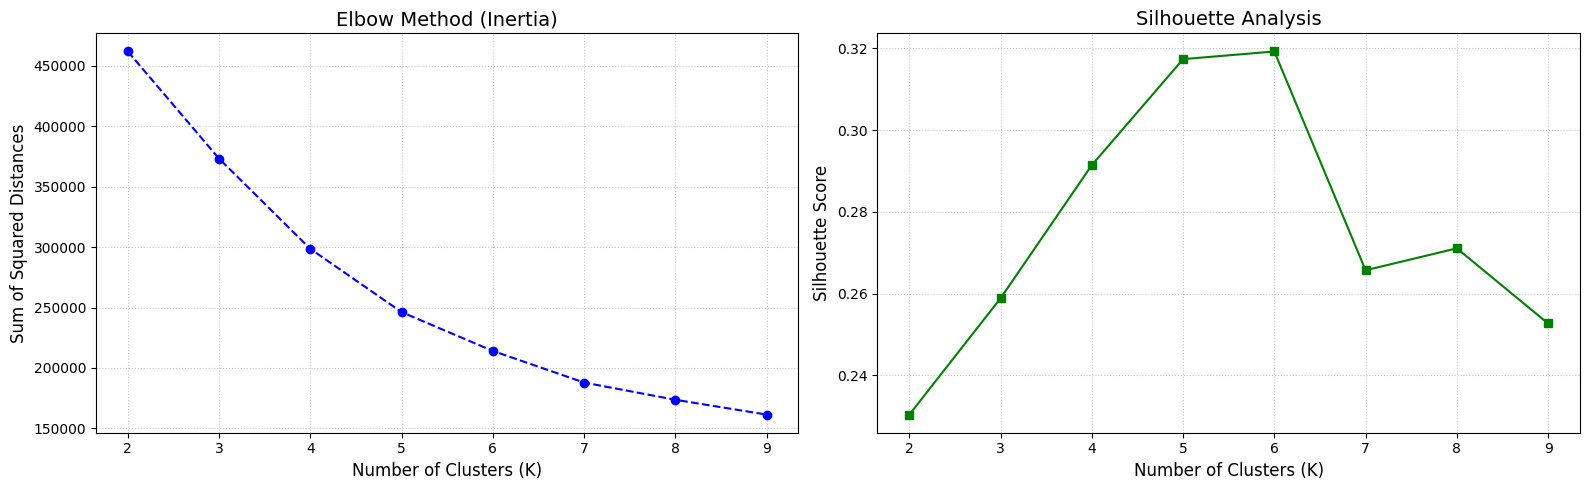

In [ ]:
from sklearn.metrics import silhouette_score
import time

inertia = []
silhouette_scores = []
K_range = range(2, 10)

print("Starting K-Means execution and metric calculation...")
start_time = time.time()

for k in K_range:
    # Train the model
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    labels = kmeans.labels_

    # 1. Calculate Inertia (for Elbow Method)
    inertia.append(kmeans.inertia_)

    # 2. Calculate Silhouette Score (use sample_size to prevent memory issues)
    sil_score = silhouette_score(X_scaled_df, labels, sample_size=15000, random_state=42)
    silhouette_scores.append(sil_score)

    print(f"K = {k} | Inertia = {kmeans.inertia_:.0f} | Silhouette Score = {sil_score:.4f}")

print(f"\nCompleted in {(time.time() - start_time):.2f} seconds.")

# ---------------------------------------------------------
# Plot results side-by-side
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Graph 1: Elbow Method
ax1.plot(K_range, inertia, marker='o', linestyle='--', color='b')
ax1.set_title('Elbow Method (Inertia)', fontsize=14)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Sum of Squared Distances', fontsize=12)
ax1.set_xticks(K_range)
ax1.grid(True, linestyle=':', alpha=0.7)

# Graph 2: Silhouette Score
ax2.plot(K_range, silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_title('Silhouette Analysis', fontsize=14)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_xticks(K_range)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

**Step 6: Train Final K-Means Model and Apply Labeling**
Based on K = 6, we will run the model one last time on the scaled dataset and assign cluster labels (0-5) back to the original `df_features` for business interpretation.

In [ ]:
# Train the final model with K = 6
final_kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
final_kmeans.fit(X_scaled_df)

# Map cluster labels to original data (non-scaled)
df_features['Cluster'] = final_kmeans.labels_

# Count customers in each cluster
cluster_counts = df_features['Cluster'].value_counts().sort_index()
print("Customer distribution per cluster:")
print(cluster_counts)

Customer distribution per cluster:
Cluster
0     2635
1    43635
2    31153
3       77
4     2763
5    13087
Name: count, dtype: int64


**Step 7: Cluster Profiling**
We will group the data by `Cluster` and calculate the mean values of the features. This answers questions like: 'How much does an average customer in Cluster 0 spend, how long do they wait for delivery, and what is their average review score?'

In [ ]:
# Group and calculate mean metrics
# Note: Use original monetary_value and avg_order_value, not the Log columns
cluster_profile = df_features.groupby('Cluster').agg({
    'frequency': 'mean',
    'monetary_value': 'mean',
    'avg_order_value': 'mean',
    'avg_delivery_time': 'mean',
    'max_delay_days': 'mean',
    'avg_freight_ratio': 'mean',
    'customer_review_score': 'mean'
}).round(2)

# Sort by Monetary value from high to low for better visibility
cluster_profile = cluster_profile.sort_values(by='monetary_value', ascending=False)
display(cluster_profile)

,frequency,monetary_value,avg_order_value,avg_delivery_time,max_delay_days,avg_freight_ratio,customer_review_score
Cluster,,,,,,,
4,2.12,309.41,146.18,11.88,0.69,0.22,4.23
3,1.00,240.53,240.53,135.65,107.81,0.18,2.97
1,1.00,226.82,226.82,10.80,0.06,0.13,4.70
0,1.01,190.95,189.19,43.56,17.14,0.22,1.69
5,1.00,176.05,176.05,15.05,0.69,0.20,1.77
2,1.00,59.08,59.08,10.95,0.07,0.32,4.61


## **6. Export data for reporting**

In [ ]:
cluster_map = {
    4: '01. Loyal Champions',
    1: '02. Potential High-Value',
    2: '03. Mass Market',
    5: '04. Product Issues',
    0: '05. Churned (Delay)',
    3: '06. Logistics Nightmare'
}

df_features['Cluster_Name'] = df_features['Cluster'].map(cluster_map)

df_features.to_csv('Olist_Customer_Segmentation_Final.csv', index=False)

print("Exported Olist_Customer_Segmentation_Final.csv success!")

Exported Olist_Customer_Segmentation_Final.csv success!
